# CSV_file_Hitters_Multinomial_Classification_Keras

### Keras 모델을 이용하여, 안타수(Hitts)와 홈런수(HmRun)로 급여(Salary)를 상중하로 예측하는 Multinomial Classification을 구현하라
### (Colab을 사용하는 경우 "files/Hitters.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))
print("Pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0
Pandas Version :2.2.2


> ### Load Data

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_06_CSV_file_Hitters_Multinomial_Classification_Keras/files/Hitters.csv'
else :
  files_path = '../files/Hitters.csv'

>### < Hitters.csv의 주요 column >
>#### AtBat : 타석수
>#### Hits : 안타수
>#### HmRun : 홈런수
>#### runs : 타점
>#### Warks : 볼넷
>#### Salary : 급여

In [4]:
# Hitters.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


> ### csv 파일 전처리

In [5]:
# 특정 column만 가져오기
df = df.loc[:, ['Hits', 'HmRun', 'Salary']]
df.head()

,Hits,HmRun,Salary
0,66,1,NaN
1,81,7,475.0
2,130,18,480.0
3,141,20,500.0
4,87,10,91.5


In [6]:
# Missing 데이터 제거
df = df.dropna()
df.head()

,Hits,HmRun,Salary
1,81,7,475.0
2,130,18,480.0
3,141,20,500.0
4,87,10,91.5
5,169,4,750.0


In [7]:
# Salary를 상(2), 중(1), 하(0)으로 구분
df.loc[df['Salary'] >= 600, 'Salary2'] = 2
df.loc[(df['Salary'] >= 250) & (df['Salary'] < 600), 'Salary2'] = 1
df.loc[df['Salary'] < 250, 'Salary2'] = 0
df.head()

,Hits,HmRun,Salary,Salary2
1,81,7,475.0,1.0
2,130,18,480.0,1.0
3,141,20,500.0,1.0
4,87,10,91.5,0.0
5,169,4,750.0,2.0


In [8]:
# Salary2가 0인 데이터 개수, 1인 데이터 개수, 2인 데이터 개수를 출력
salary2 = df['Salary2']
print(salary2.value_counts())

Salary2
2.0    97
0.0    87
1.0    79
Name: count, dtype: int64


In [9]:
input = np.array(df[['Hits', 'HmRun']], dtype= np.float32)
target = np.array(df['Salary2'], dtype= np.float32).reshape((-1,1))

In [10]:
print(input.shape)
print(input[:10])
print(target.shape)
print(target[:10])

(263, 2)
[[ 81.   7.]
 [130.  18.]
 [141.  20.]
 [ 87.  10.]
 [169.   4.]
 [ 37.   1.]
 [ 73.   0.]
 [ 81.   6.]
 [ 92.  17.]
 [159.  21.]]
(263, 1)
[[1.]
 [1.]
 [1.]
 [0.]
 [2.]
 [0.]
 [0.]
 [0.]
 [2.]
 [1.]]


In [11]:
target_onehot = tf.one_hot(target.reshape((-1,)), 3)

x_input = tf.constant(input, dtype=tf.float32)
labels = tf.constant(target_onehot, dtype=tf.float32)

In [12]:
print(x_input.shape)
print(x_input[:10])
print(labels.shape)
print(labels[:10])

(263, 2)
tf.Tensor(
[[ 81.   7.]
 [130.  18.]
 [141.  20.]
 [ 87.  10.]
 [169.   4.]
 [ 37.   1.]
 [ 73.   0.]
 [ 81.   6.]
 [ 92.  17.]
 [159.  21.]], shape=(10, 2), dtype=float32)
(263, 3)
tf.Tensor(
[[0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]], shape=(10, 3), dtype=float32)


In [13]:
# 1. Min Max Scaler 적용


In [15]:
# 2. Keras Model 정의, Model compile, Model summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 3)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3. Model Fit

In [16]:
%%time


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Epoch 2502/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5317 - loss: 0.9856 
Epoch 2503/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5270 - loss: 0.9950 
Epoch 2504/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4977 - loss: 0.9993 
Epoch 2505/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5111 - loss: 1.0068 
Epoch 2506/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5175 - loss: 0.9962 
Epoch 2507/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4515 - loss: 1.0236 
Epoch 2508/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5126 - loss: 0.9997 
Epoch 2509/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4873 - loss: 1.0284 
Epoch 2510/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5288 - loss: 0.9839 
Epoch 2511/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5402 - loss: 0.9685 
Epoch 2512/5000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5380 - loss: 1.00

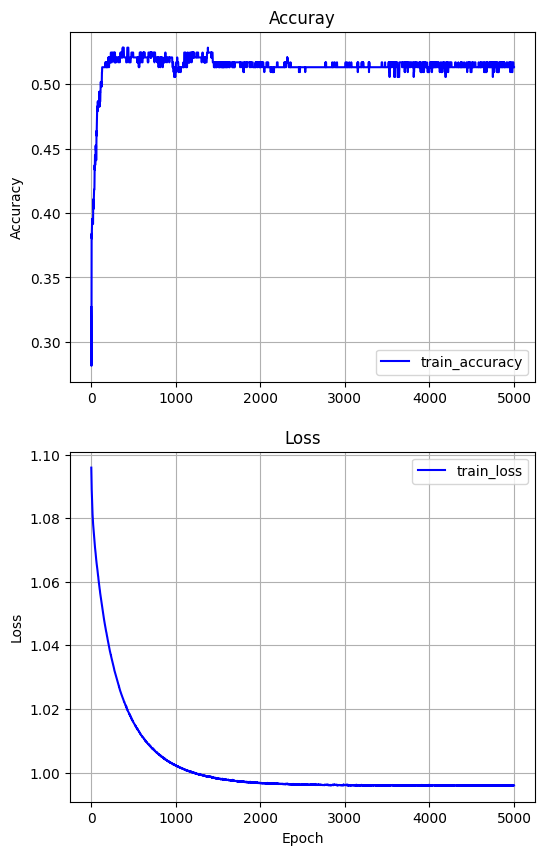

In [17]:
# 4. accuray, loss 그래프 출력


In [18]:
# 5. parameter(W,B) 출력


[array([[-2.628646  , -1.4956424 ,  2.6417513 ],
       [-0.5681039 , -0.42765522,  0.43050438]], dtype=float32), array([ 1.0560228,  0.4959617, -1.5443852], dtype=float32)]


In [19]:
# 6. Predict (x_input 사용)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
x:[0.33755276 0.175     ], h:[0.41983    0.3602563  0.21991374], l:[0. 1. 0.]
x:[0.5443038 0.45     ], h:[0.23940898 0.26988938 0.49070156], l:[0. 1. 0.]
x:[0.5907173 0.5      ], h:[0.20209226 0.2418148  0.55609286], l:[0. 1. 0.]
x:[0.3628692 0.25     ], h:[0.39407948 0.35168496 0.25423563], l:[1. 0. 0.]
x:[0.70886075 0.1       ], h:[0.1744267  0.2255699  0.60000336], l:[0. 0. 1.]
x:[0.15189873 0.025     ], h:[0.5404439  0.3679484  0.09160764], l:[1. 0. 0.]
x:[0.30379745 0.        ], h:[0.45998237 0.37067685 0.16934083], l:[1. 0. 0.]
x:[0.33755276 0.15      ], h:[0.42265537 0.36140957 0.21593502], l:[1. 0. 0.]
x:[0.38396624 0.425     ], h:[0.3577247  0.33509985 0.30717537], l:[0. 0. 1.]
x:[0.6666667 0.525    ], h:[0.15340587 0.2007574  0.6458367 ], l:[0. 1. 0.]
x:[0.21940929 0.1       ], h:[0.49913058 0.37071848 0.13015091], l:[0. 1. 0.]
x:[0.47257385 0.325     ], h:[0.30666956 0.31318164 0.3801487 ], l:[0. 1. 0.]
x:[0.24894515 0.        ], h:[0.49

In [20]:
# 7.  (Hits가 171, HmRun이 10일 때 Salay를 0, 1, 2로 예측)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step

[ Prediction by specific data ]
Hits : 171.0, HmRun : 10.0 = > Salay : 2 ([[0.1535894 0.2048006 0.64161  ]])


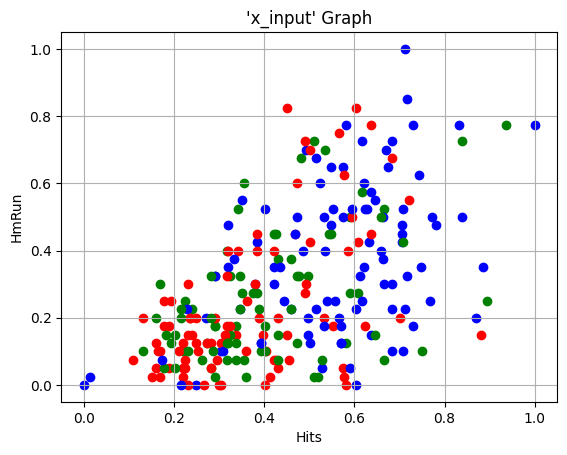

In [21]:
# 8. x_input을 시각화 -> Hits를 x축, HmRun을 y축으로 -> labels에 따라 색깔을 R(0), G(1), B(2) dot로 표시하는 그래프 출력
